In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('activemq-5.0.0.csv')

df.head()

,File,CountDeclMethodPrivate,AvgLineCode,CountLine,MaxCyclomatic,CountDeclMethodDefault,AvgEssential,CountDeclClassVariable,SumCyclomaticStrict,AvgCyclomatic,...,OWN_LINE,OWN_COMMIT,MINOR_COMMIT,MINOR_LINE,MAJOR_COMMIT,MAJOR_LINE,HeuBug,HeuBugCount,RealBug,RealBugCount
0,activemq-console/src/main/java/org/apache/acti...,0,10,171,5,0,2,0,18,2,...,1.00000,1.0,0,1,1,0,False,0,False,0
1,activemq-console/src/main/java/org/apache/acti...,0,8,123,5,0,1,1,15,3,...,0.98374,0.5,0,1,2,1,False,0,False,0
2,activemq-console/src/main/java/org/apache/acti...,0,7,136,5,0,1,1,16,2,...,1.00000,1.0,0,1,1,0,False,0,False,0
3,activemq-console/src/main/java/org/apache/acti...,0,29,241,17,0,4,5,29,9,...,1.00000,1.0,0,1,1,0,False,0,False,0
4,activemq-console/src/main/java/org/apache/acti...,0,24,212,17,0,3,5,26,8,...,1.00000,1.0,0,1,1,0,False,0,False,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1884 entries, 0 to 1883
Data columns (total 70 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   File                       1884 non-null   object 
 1   CountDeclMethodPrivate     1884 non-null   int64  
 2   AvgLineCode                1884 non-null   int64  
 3   CountLine                  1884 non-null   int64  
 4   MaxCyclomatic              1884 non-null   int64  
 5   CountDeclMethodDefault     1884 non-null   int64  
 6   AvgEssential               1884 non-null   int64  
 7   CountDeclClassVariable     1884 non-null   int64  
 8   SumCyclomaticStrict        1884 non-null   int64  
 9   AvgCyclomatic              1884 non-null   int64  
 10  AvgLine                    1884 non-null   int64  
 11  CountDeclClassMethod       1884 non-null   int64  
 12  AvgLineComment             1884 non-null   int64  
 13  AvgCyclomaticModified      1884 non-null   int64

In [3]:
df = df.drop(columns=['HeuBug', 'HeuBugCount', 'RealBugCount'])

In [4]:
df.shape

(1884, 67)

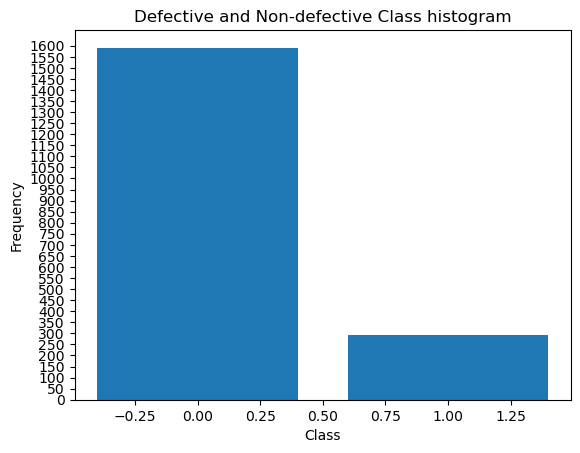

In [5]:
#Defective and Non-defective Class histogram
import matplotlib.pyplot as plt

# Count the occurrences of each class
class_counts = df['RealBug'].value_counts()

# Plot the histogram
plt.bar(class_counts.index, class_counts.values)
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.title('Defective and Non-defective Class histogram')
plt.xticks(rotation=0)
# show more numbers in frequency (y axis)
plt.gca().set_yticks(range(0, class_counts.max() + 50, 50))
# show the grid
# plt.grid(axis='y')
plt.show()


In [6]:
class_counts

RealBug
False    1591
True      293
Name: count, dtype: int64

<Axes: xlabel='RealBug', ylabel='CountLineCode'>

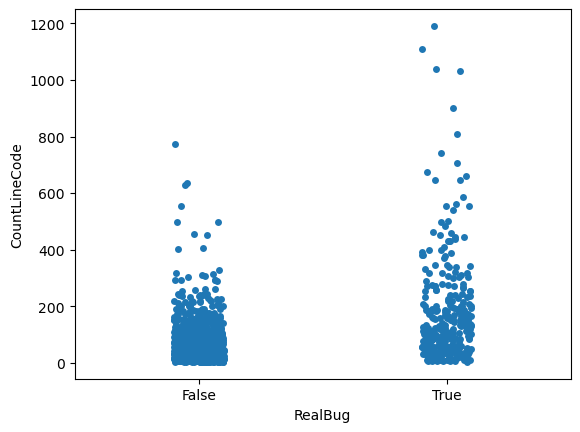

In [7]:
# Dispersion plot of class Defective
import seaborn as sns

sns.stripplot(x='RealBug', y='CountLineCode', data=df, jitter=True)

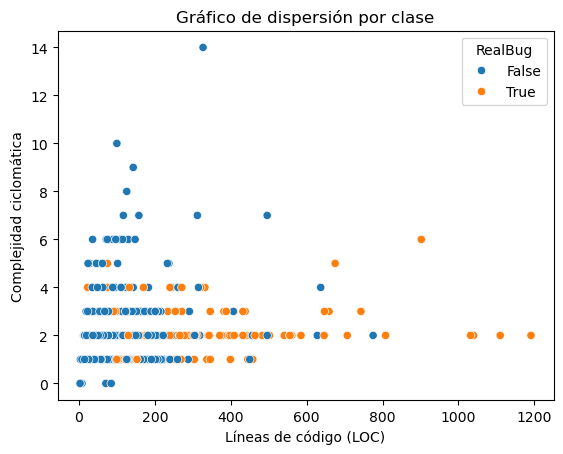

In [8]:
    # Suponiendo que las columnas relevantes para la visualización se llaman 'metric_1', 'metric_2' y 'class'
# Reemplaza 'metric_1' y 'metric_2' con los nombres reales de las columnas que quieres visualizar.
# 'class' es la columna que contiene la etiqueta de clase (defecto o no defecto).
sns.scatterplot(x='CountLineCode', y='AvgCyclomatic', hue='RealBug', data=df)

# Añadir títulos y etiquetas
plt.title('Gráfico de dispersión por clase')
plt.xlabel('Líneas de código (LOC)')
plt.ylabel('Complejidad ciclomática')
plt.show()

## Preprocesamiento

- isNull / Missing values
- Duplicados
- Outlaiers
- Transformación de los datos - Normalización/Estandarización (MinMax, z-score)
- Balanceo de clases
> SMOTE segun papers
- Seleccion de caracteristicas (arbol de decision - CABOOST) 
- Reduccion de Dimensionalidad (PCA)
- Particion Train/Test

### Missing Values

In [9]:
df.isnull().sum()

File                      0
CountDeclMethodPrivate    0
AvgLineCode               0
CountLine                 0
MaxCyclomatic             0
                         ..
MINOR_COMMIT              0
MINOR_LINE                0
MAJOR_COMMIT              0
MAJOR_LINE                0
RealBug                   0
Length: 67, dtype: int64

### Duplicated

In [10]:
df.duplicated().sum()

0

### Outliers

In [ ]:
from sklearn.preprocessing import StandardScaler

df_numeric = df.select_dtypes(include=['float64', 'int64'])
scaler = StandardScaler()
df_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_numeric), columns=df_numeric.columns)

In [38]:
df_numeric.describe()

,CountDeclMethodPrivate,AvgLineCode,CountLine,MaxCyclomatic,CountDeclMethodDefault,AvgEssential,CountDeclClassVariable,SumCyclomaticStrict,AvgCyclomatic,AvgLine,...,ADEV,DDEV,Added_lines,Del_lines,OWN_LINE,OWN_COMMIT,MINOR_COMMIT,MINOR_LINE,MAJOR_COMMIT,MAJOR_LINE
count,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,...,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.000000,1884.00000,1884.000000,1884.000000
mean,0.245223,6.675690,131.980361,2.932590,0.682059,1.063694,0.664013,15.209130,1.493100,9.168790,...,2.822718,1.220807,44.551486,38.695329,0.751368,0.930954,0.000531,2.02017,1.220276,0.321656
std,0.994063,5.957579,149.558899,3.387086,3.216275,0.322922,1.565751,23.907522,0.947061,7.842188,...,1.950909,0.449313,89.982922,80.045258,0.195773,0.144749,0.023039,0.80599,0.447798,0.588018
min,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,0.000000,0.333333,0.333333,0.000000,1.00000,1.000000,0.000000
25%,0.000000,3.000000,51.750000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000,5.000000,...,2.000000,1.000000,4.000000,4.000000,0.567568,1.000000,0.000000,1.00000,1.000000,0.000000
50%,0.000000,5.000000,94.000000,2.000000,0.000000,1.000000,0.000000,7.000000,1.000000,7.000000,...,2.000000,1.000000,16.000000,15.000000,0.750000,1.000000,0.000000,2.00000,1.000000,0.000000
75%,0.000000,8.000000,149.250000,4.000000,0.000000,1.000000,1.000000,17.000000,2.000000,11.000000,...,3.000000,1.000000,46.000000,37.000000,0.968750,1.000000,0.000000,3.00000,1.000000,1.000000
max,21.000000,63.000000,2075.000000,56.000000,44.000000,4.000000,23.000000,301.000000,14.000000,75.000000,...,23.000000,4.000000,1402.000000,1326.000000,1.000000,1.000000,1.000000,5.00000,4.000000,4.000000


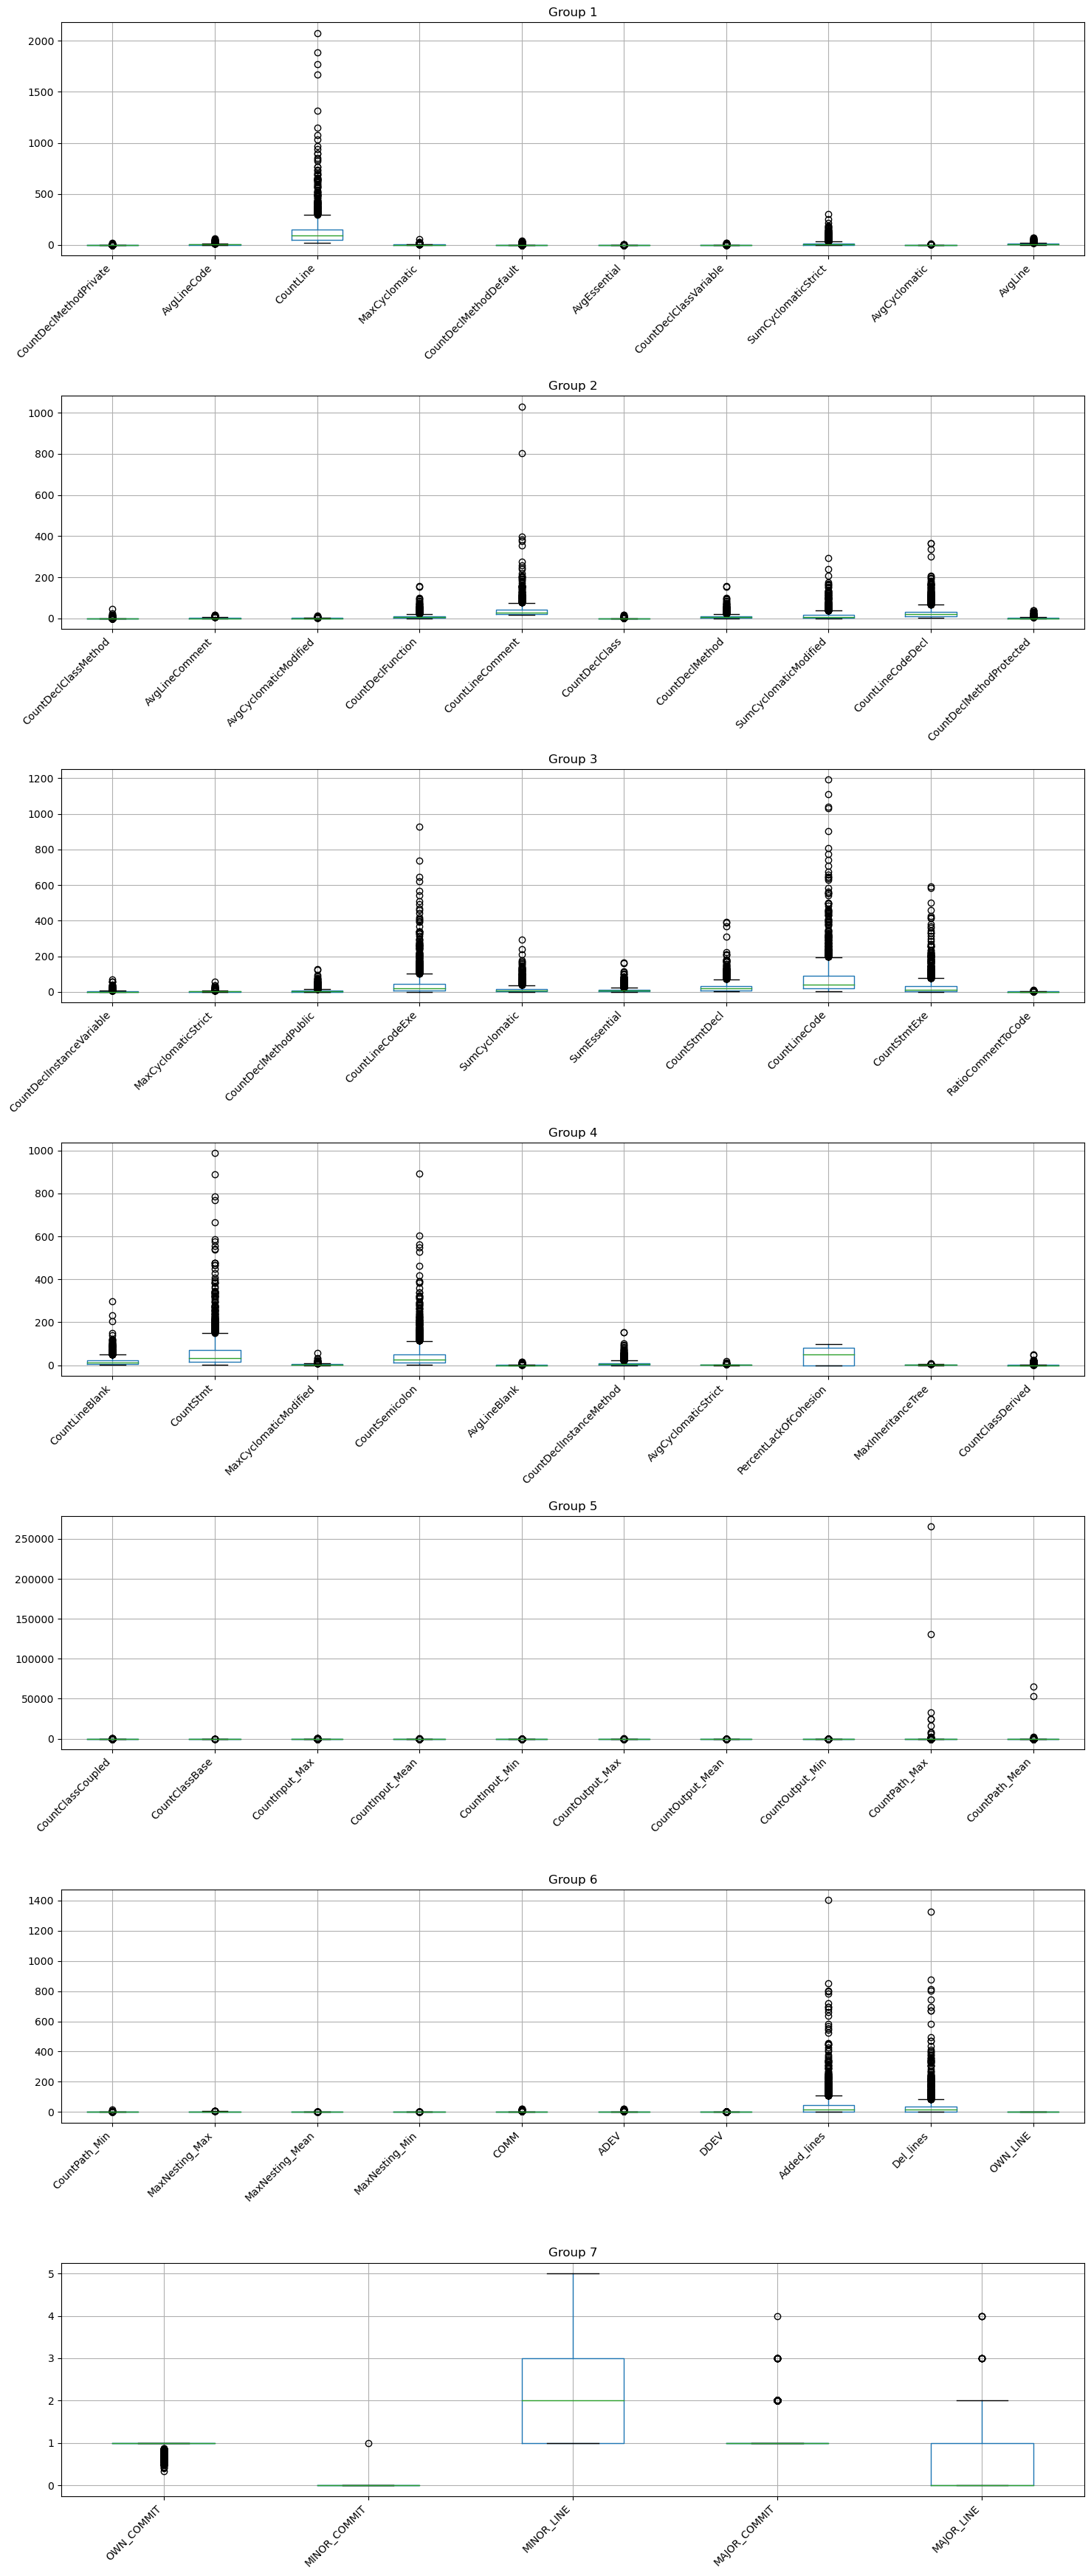

In [28]:
# Divide the numeric columns into groups of 10 for better visualization
n_cols = len(df_numeric.columns)
group_size = 10
groups = [df_numeric.columns[i*group_size:(i+1)*group_size] for i in range(n_cols // group_size)]
if n_cols % group_size != 0:
    groups.append(df_numeric.columns[(n_cols // group_size)*group_size:])

# Create subplots based on number of groups
fig, axes = plt.subplots(len(groups), 1, figsize=(15, 5 * len(groups)))
if len(groups) == 1:
    axes = [axes]

for i, group in enumerate(groups):
    df_numeric[group].boxplot(ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_title(f'Group {i+1}')

plt.tight_layout()
plt.show()


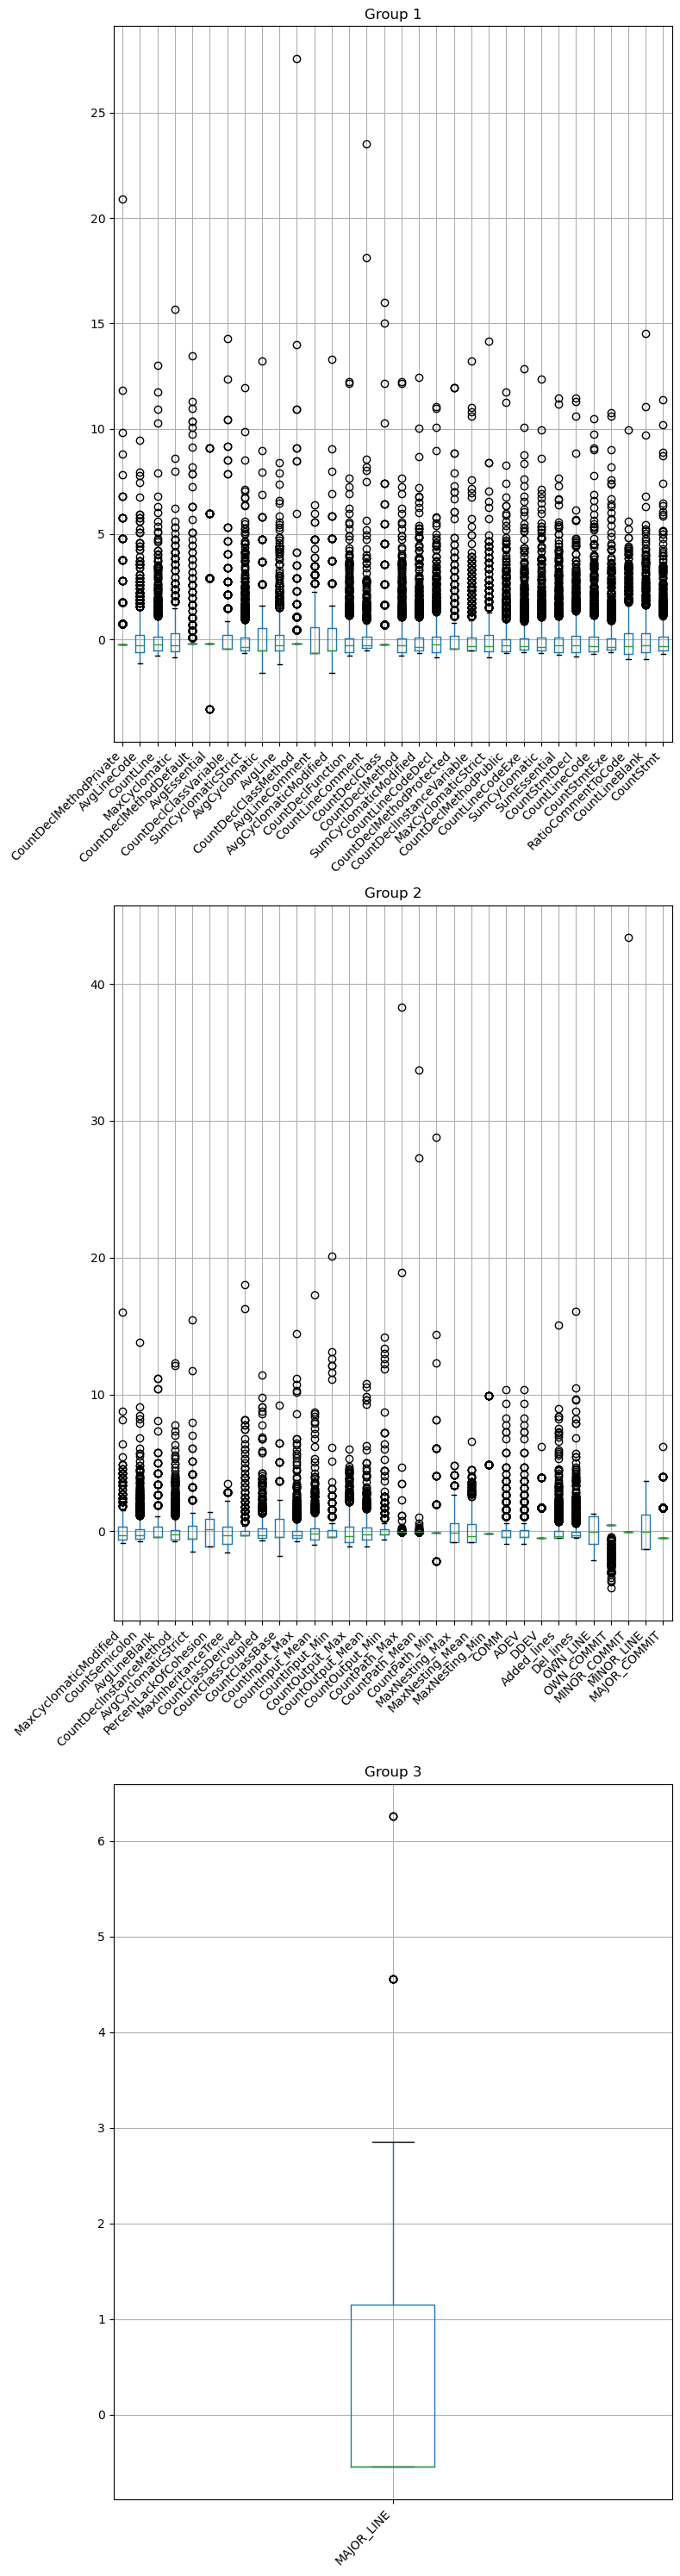

In [44]:
# Divide the numeric columns into groups of 10 for better visualization
n_cols = len(df_numeric.columns)
group_size = 32
groups = [df_numeric.columns[i*group_size:(i+1)*group_size] for i in range(n_cols // group_size)]
if n_cols % group_size != 0:
    groups.append(df_numeric.columns[(n_cols // group_size)*group_size:])

# Create subplots based on number of groups
fig, axes = plt.subplots(len(groups), 1, figsize=(8, 10 * len(groups)))
if len(groups) == 1:
    axes = [axes]

for i, group in enumerate(groups):
    df_numeric_scaled[group].boxplot(ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_title(f'Group {i+1}')

plt.tight_layout()
plt.show()

In [39]:
median = df_numeric.median()
mad = (df_numeric - median).abs().median()
df_numeric_mad = (df_numeric - median).abs() / mad


/opt/homebrew/Caskroom/miniconda/base/envs/mineria1/lib/python3.8/site-packages/numpy/lib/function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/opt/homebrew/Caskroom/miniconda/base/envs/mineria1/lib/python3.8/site-packages/numpy/lib/function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/opt/homebrew/Caskroom/miniconda/base/envs/mineria1/lib/python3.8/site-packages/numpy/lib/function_base.py:4573: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


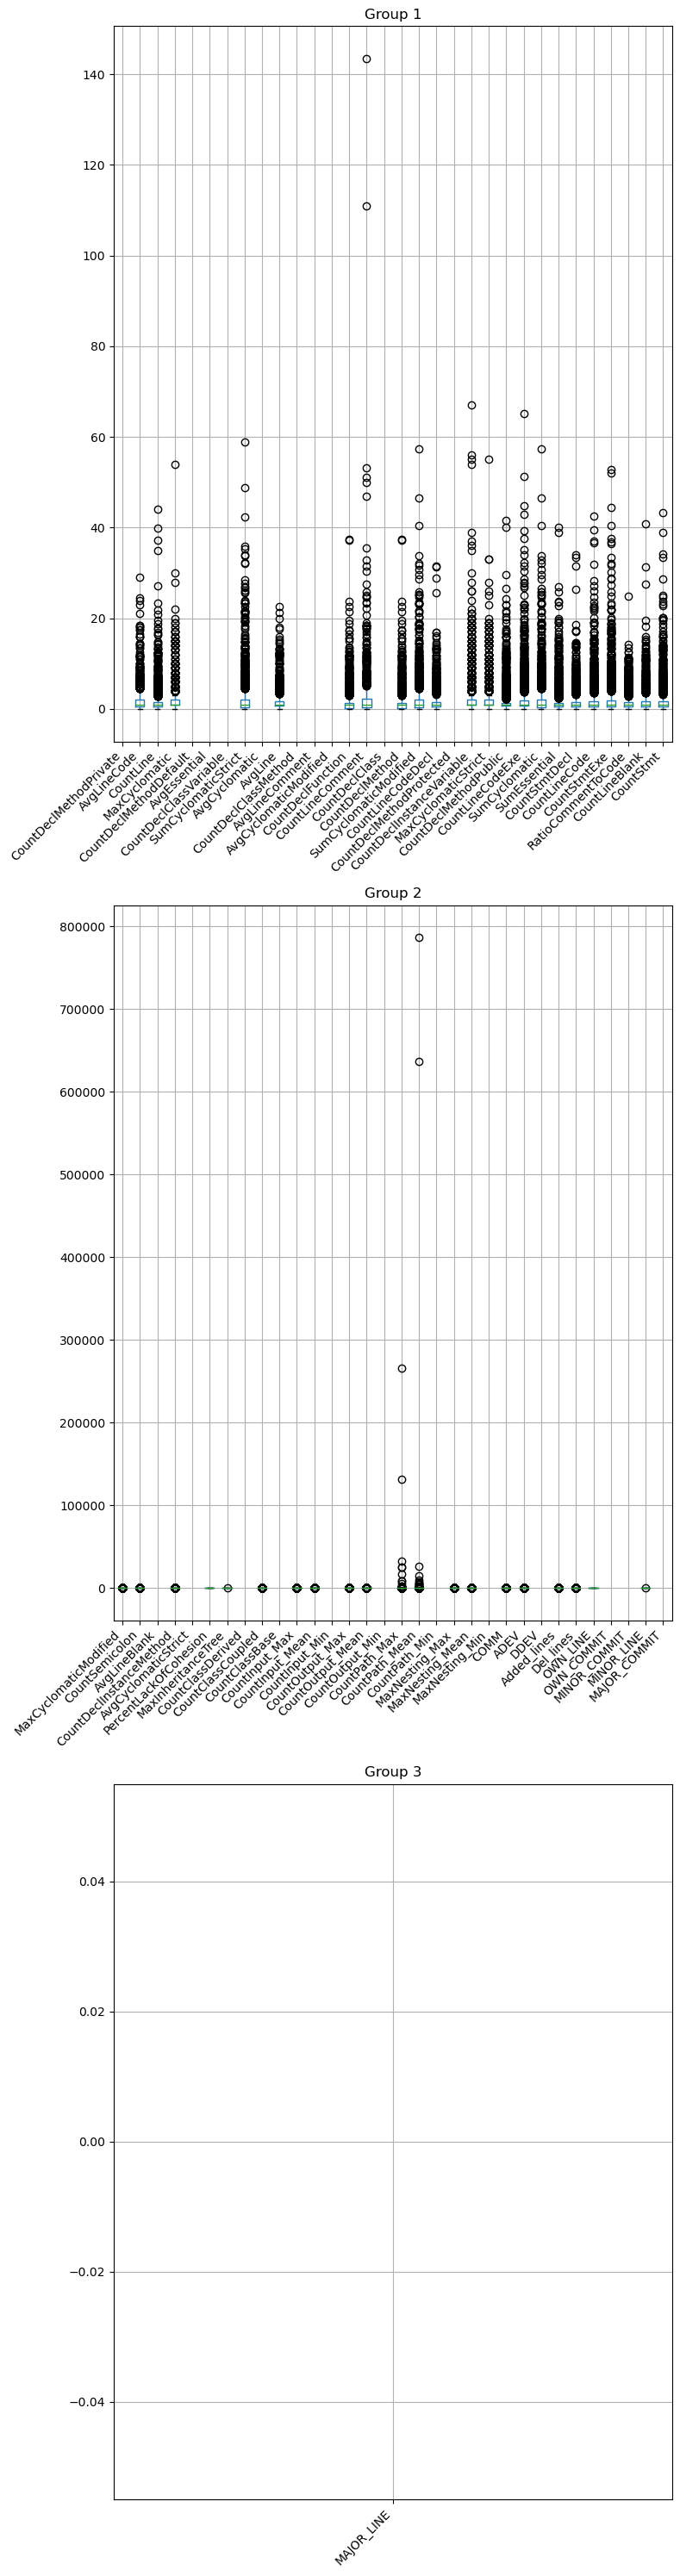

In [40]:
# Divide the numeric columns into groups of 10 for better visualization
n_cols = len(df_numeric.columns)
group_size = 32
groups = [df_numeric.columns[i*group_size:(i+1)*group_size] for i in range(n_cols // group_size)]
if n_cols % group_size != 0:
    groups.append(df_numeric.columns[(n_cols // group_size)*group_size:])

# Create subplots based on number of groups
fig, axes = plt.subplots(len(groups), 1, figsize=(8, 10 * len(groups)))
if len(groups) == 1:
    axes = [axes]

for i, group in enumerate(groups):
    df_numeric_mad[group].boxplot(ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_title(f'Group {i+1}')

plt.tight_layout()
plt.show()

In [43]:
# Remove outliers based on standardscaler (keeping rows where all scaled values are within -3 to 3 standard deviations)
threshold = 3
mask = (df_numeric_scaled.abs() <= threshold).all(axis=1)
df_cleaned = df[mask]
df_cleaned.shape

(1420, 67)

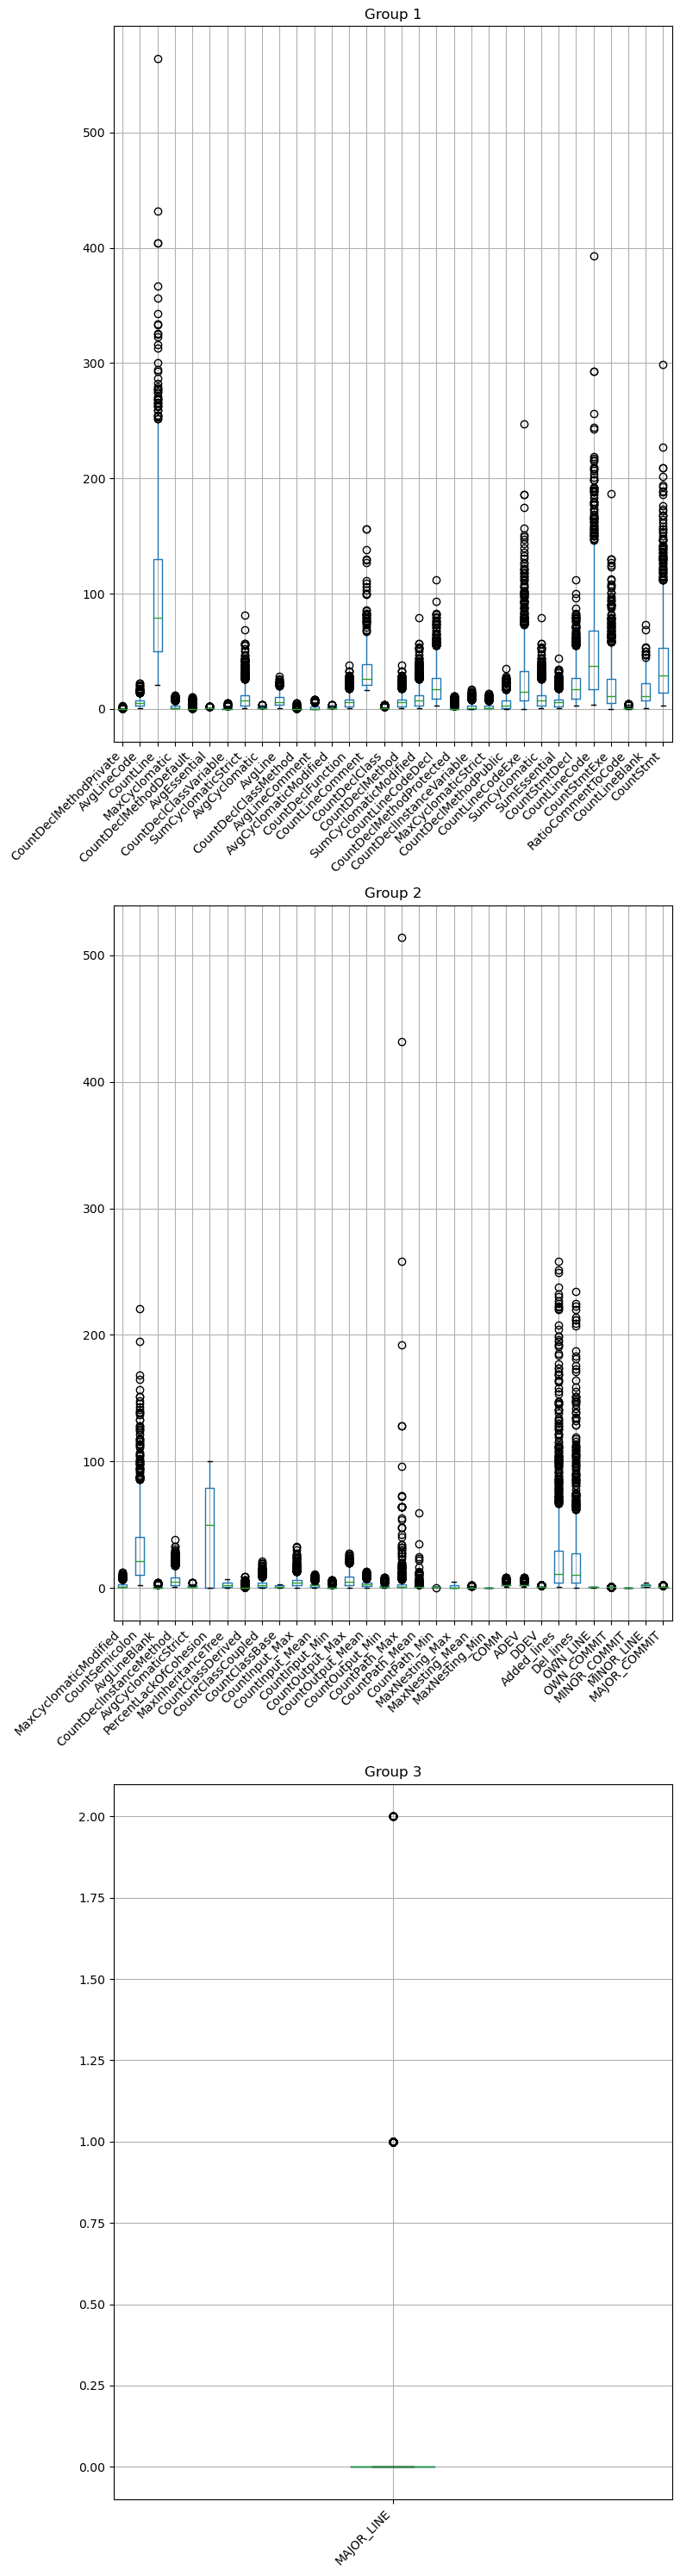

In [45]:
# Divide the numeric columns into groups of 10 for better visualization
n_cols = len(df_numeric.columns)
group_size = 32
groups = [df_numeric.columns[i*group_size:(i+1)*group_size] for i in range(n_cols // group_size)]
if n_cols % group_size != 0:
    groups.append(df_numeric.columns[(n_cols // group_size)*group_size:])

# Create subplots based on number of groups
fig, axes = plt.subplots(len(groups), 1, figsize=(8, 10 * len(groups)))
if len(groups) == 1:
    axes = [axes]

for i, group in enumerate(groups):
    df_cleaned[group].boxplot(ax=axes[i])
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    axes[i].set_title(f'Group {i+1}')

plt.tight_layout()
plt.show()